# Preprocessing of application columns
- table - app_train.csv, app_valid.csv
---

__Loan info__:
- `AMT_CREDIT` - Credit amount of the loan
- `AMT_ANNUITY` - Loan annuity
- `AMT_GOODS_PRICE` - For consumer loans it is the price of the goods for which the loan is given

## 0. Libraries and Data

In [ ]:
import pandas as pd
import numpy as np

from optbinning import OptimalBinning

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_quantitative_vs_binary, plot_categorical_distribution,
    plot_categorical_vs_binary
)

from preprocess_module import (
    bin_quantitative_var, fit_optbin_var
)

In [44]:
df_train = pd.read_csv(r"..\..\data\interim\app_train.csv")
print(f"Shape of df_train: {df_train.shape}")
df_train.head(10)

Shape of df_train: (215257, 122)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,285133,Cash loans,F,Y,Y,2,405000.0,1971072.0,68643.0,1800000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,191894,Cash loans,M,N,Y,0,337500.0,508495.5,38146.5,454500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,6.0,0
2,369428,Cash loans,M,N,Y,1,112500.0,110146.5,13068.0,90000.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,138717,Cash loans,F,N,Y,2,40500.0,66384.0,3519.0,45000.0,...,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0,0
4,202381,Cash loans,M,Y,N,0,225000.0,298512.0,31801.5,270000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,185763,Cash loans,F,N,Y,0,315000.0,417024.0,21964.5,360000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0
6,148765,Cash loans,M,Y,Y,0,162000.0,168102.0,11362.5,148500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
7,448028,Cash loans,F,N,Y,0,135000.0,1129500.0,33025.5,1129500.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
8,428649,Cash loans,F,N,Y,0,157500.0,1260702.0,39712.5,1129500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
9,345767,Cash loans,F,Y,N,0,180000.0,879480.0,25843.5,630000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,0


In [45]:
df_valid = pd.read_csv(r"..\..\data\interim\app_valid.csv")
print(f"Shape of df_valid: {df_valid.shape}")
df_valid.head(10)

Shape of df_valid: (92254, 122)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET
0,331034,Cash loans,F,N,Y,0,90000.0,803259.0,23616.0,670500.0,...,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0
1,242581,Cash loans,F,N,Y,0,270000.0,1288350.0,41692.5,1125000.0,...,0,0,0,0.0,0.0,0.0,1.0,0.0,4.0,0
2,281583,Cash loans,F,N,Y,0,270000.0,253737.0,25227.0,229500.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,255865,Cash loans,F,N,Y,0,144000.0,436032.0,16564.5,360000.0,...,0,0,0,0.0,0.0,1.0,0.0,0.0,2.0,0
4,389379,Revolving loans,M,N,N,2,72000.0,225000.0,11250.0,225000.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0
5,455506,Cash loans,M,Y,Y,0,315000.0,521280.0,27423.0,450000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0
6,234885,Cash loans,F,Y,Y,1,54000.0,102384.0,6673.5,81000.0,...,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0,0
7,425217,Cash loans,M,Y,N,0,315000.0,545040.0,31288.5,450000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,0
8,209875,Cash loans,F,N,Y,1,315000.0,254700.0,13567.5,225000.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,106521,Cash loans,F,Y,N,0,67500.0,292500.0,13014.0,292500.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0


## 1. AMT_CREDIT

In [46]:
df_train['AMT_CREDIT'].describe()

count    2.152570e+05
mean     5.994164e+05
std      4.026477e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.163975e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

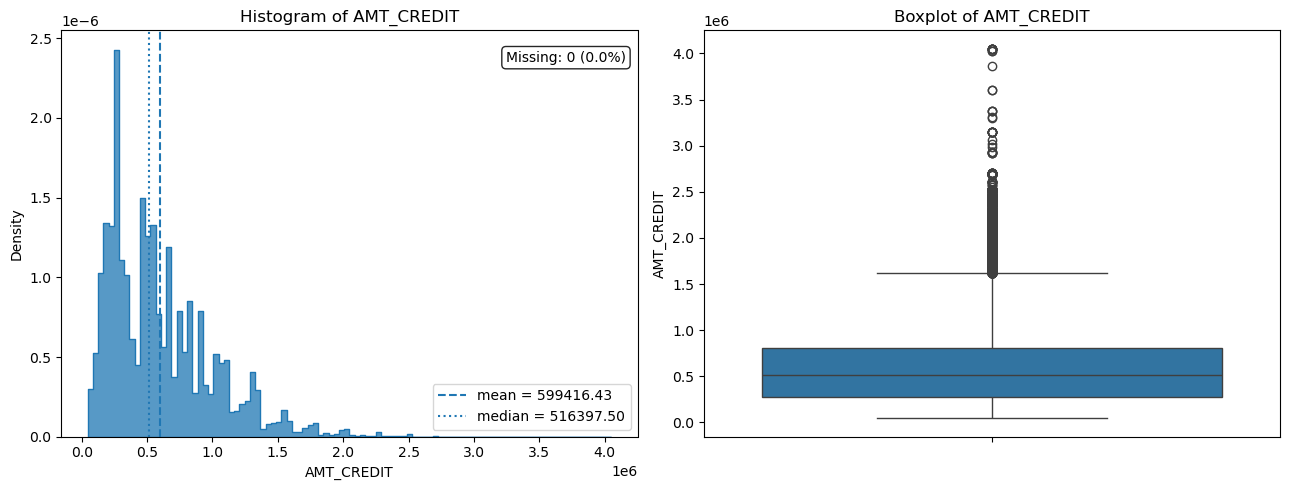

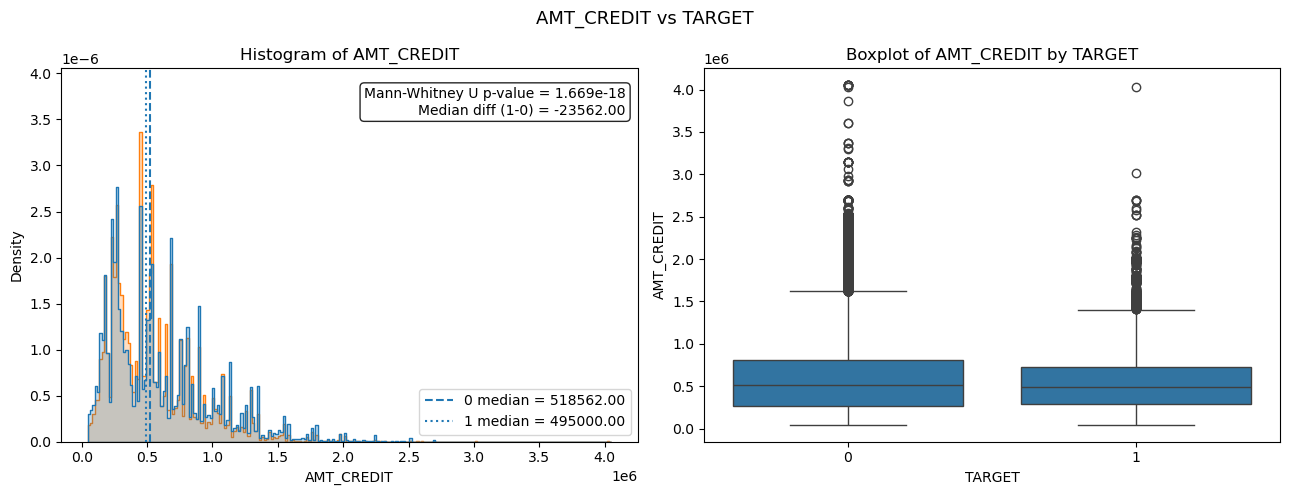

In [57]:
plot_quantitative_distribution(df=df_train, quant_var='AMT_CREDIT', hist_bins=100)
plot_quantitative_vs_binary(df=df_train, quant_var='AMT_CREDIT', target_var='TARGET')

In [48]:
amt_credit_binned, df1, amt_quantiles_summary = bin_quantitative_var(
    df = df_train,
    quant_var='AMT_CREDIT',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=True,
    return_summary=True,
    return_df=True
)

amt_quantiles_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q1,45438,0.211087,3302,42136,0.072670
1,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q2,40708,0.189113,3756,36952,0.092267
2,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q3,43016,0.199836,4328,38688,0.100614
3,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q4,44808,0.208160,3496,41312,0.078022
4,AMT_CREDIT,AMT_CREDIT_binned_quantiles,quantiles,Q5,41287,0.191803,2495,38792,0.060431


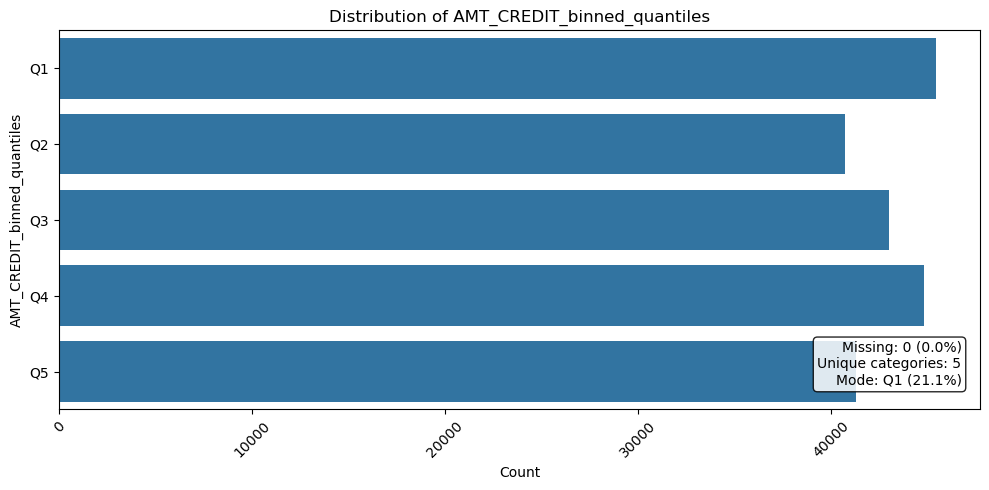

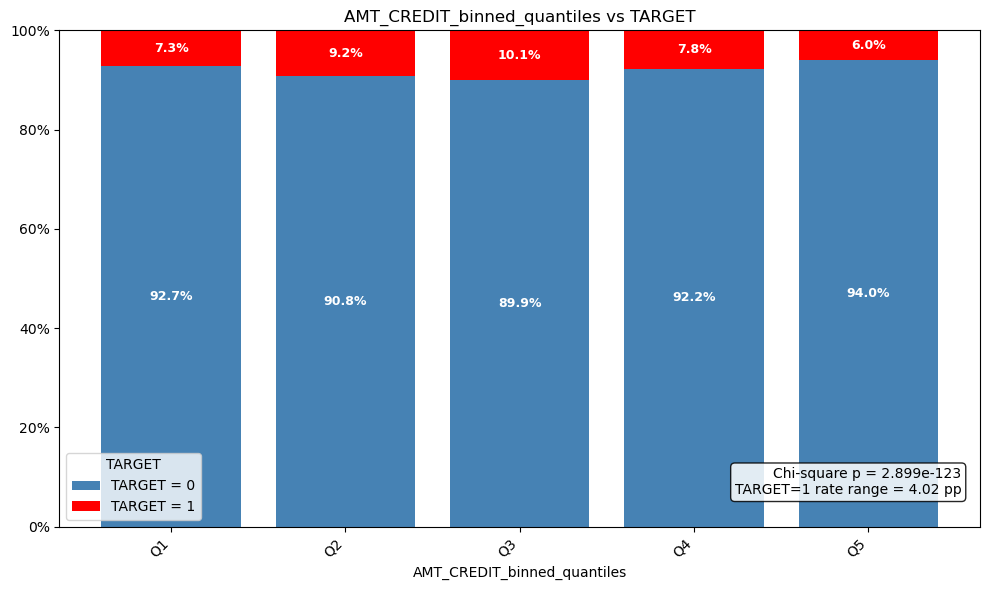

In [49]:
plot_categorical_distribution(df=df1, cat_var='AMT_CREDIT_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=df1, cat_var='AMT_CREDIT_binned_quantiles', target_var='TARGET', respect_category_order=True)

In [55]:
df1, df_valid1, optb, bt = fit_optbin_var(
    df_train=df1,
    df_valid=df_valid,
    var="AMT_CREDIT",
    dtype='numerical',
    target="TARGET",
    metric="woe",
    monotonic_trend="auto",
    min_bin_size=0.05
)

In [ ]:
df1, df_valid1, optb, bt = fit_optbin_var(
    df_train=df1,
    df_valid=df_valid1,
    var="AMT_CREDIT",
    dtype='numerical',
    target="TARGET",
    metric="bins",
    monotonic_trend="auto",
    min_bin_size=0.05
)

In [52]:
bt

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 158683.50)",15193,0.070581,14270,923,0.060752,0.305772,0.005809,0.000723
1,"[158683.50, 274104.00)",40441,0.187873,37317,3124,0.077248,0.047821,0.000421,0.000053
2,"[274104.00, 338715.00)",17115,0.079510,15509,1606,0.093836,-0.164839,0.002315,0.000289
3,"[338715.00, 407477.25)",10772,0.050043,9681,1091,0.101281,-0.249443,0.003457,0.000431
4,"[407477.25, 453440.25)",11468,0.053276,10109,1359,0.118504,-0.425836,0.011549,0.001433
5,"[453440.25, 672320.25)",41299,0.191859,37258,4041,0.097847,-0.211139,0.009346,0.001166
6,"[672320.25, 898380.00)",33237,0.154406,30740,2497,0.075127,0.077961,0.000908,0.000114
7,"[898380.00, 1101435.75)",20132,0.093525,18764,1368,0.067952,0.186077,0.002996,0.000374
8,"[1101435.75, 1345173.75)",13939,0.064755,13084,855,0.061339,0.295531,0.005000,0.000623
9,"[1345173.75, inf)",11661,0.054172,11148,513,0.043993,0.646226,0.017329,0.002129


In [53]:
df1.columns

Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'TARGET', 'AMT_CREDIT_binned_quantiles',
       'AMT_CREDIT_optbin_bin'],
      dtype='object', length=124)

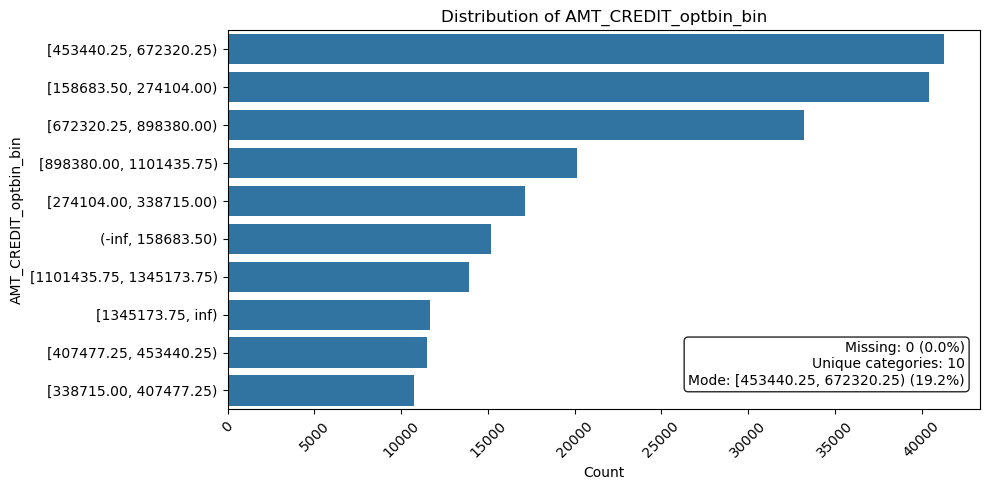

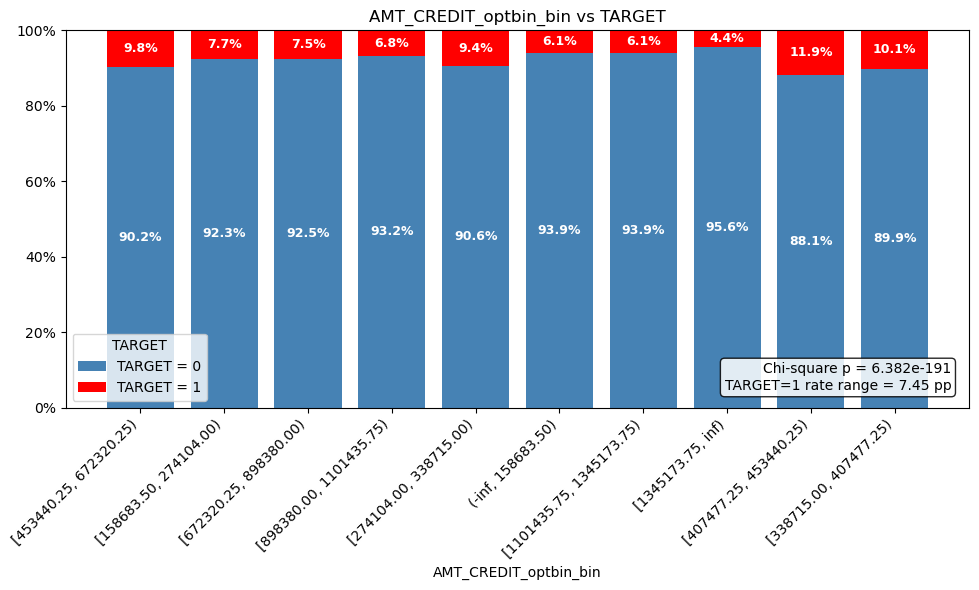

In [54]:
plot_categorical_distribution(df=df1, cat_var='AMT_CREDIT_optbin_bin', respect_category_order=True)
plot_categorical_vs_binary(df=df1, cat_var='AMT_CREDIT_optbin_bin', target_var='TARGET', respect_category_order=True)

## 2. AMT_ANNUITY